Loading metrics data...
Loaded 96 records

Sample data:
  test_type  mean_res       config  mean_waiting_time  total_energy_waste
0      easy         1    smart_t60         112.919478        5.211689e+06
1      easy         1  batsim_t480          22.735693        1.144262e+07
2      easy         2  batsim_t180         117.490216        1.864495e+07
3      easy         4  batsim_t600          55.802947        4.951476e+07
4      easy         8  batsim_t420         252.109392        7.679666e+07
Data with derived columns:
  test_type  mean_res       config timeout scheduler  mean_waiting_time  \
0      easy         1    smart_t60     t60     smart         112.919478   
1      easy         1  batsim_t480    t480    batsim          22.735693   
2      easy         2  batsim_t180    t180    batsim         117.490216   
3      easy         4  batsim_t600    t600    batsim          55.802947   
4      easy         8  batsim_t420    t420    batsim         252.109392   

   total_energy_waste 

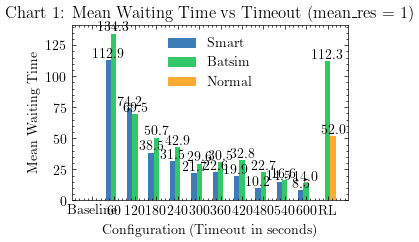

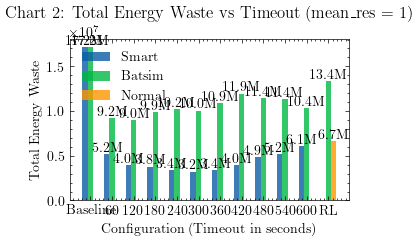


Generating charts for mean_res = 2


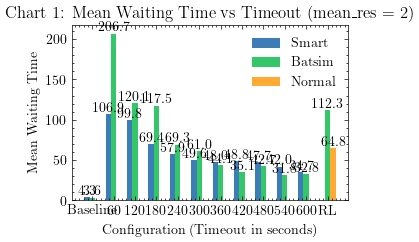

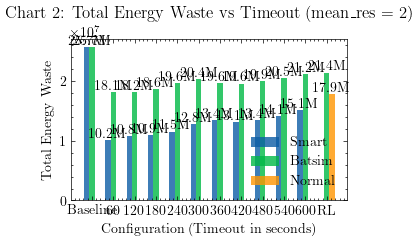


Generating charts for mean_res = 4


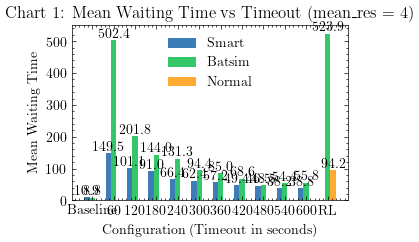

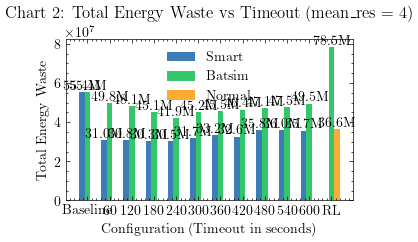


Generating charts for mean_res = 8


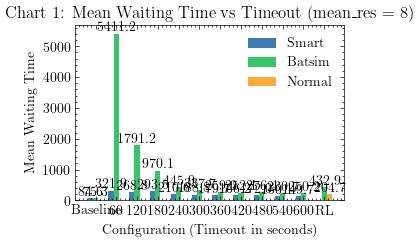

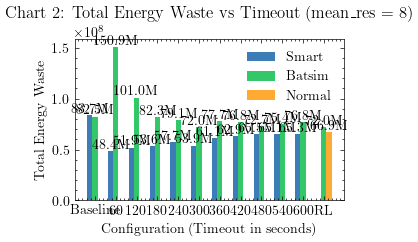


Generating charts for timeout = t300


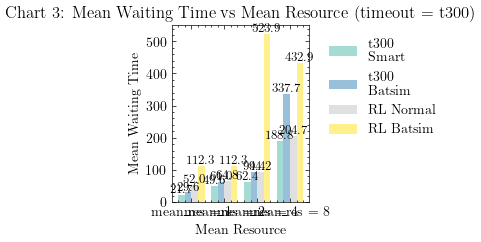

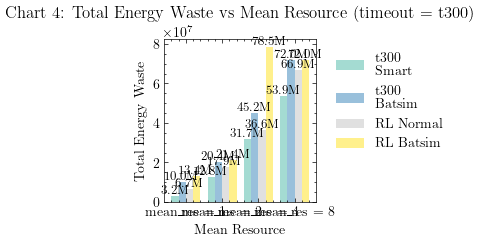


Generating charts for timeout = baseline


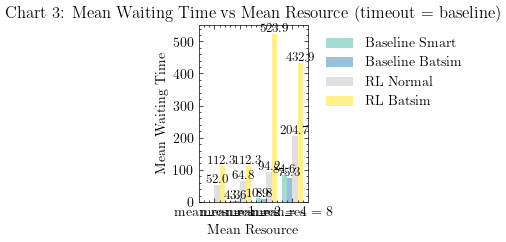

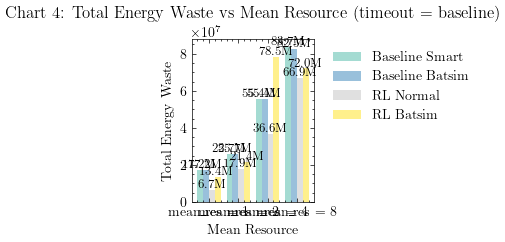

Summary Statistics:
Total records loaded: 96
Unique mean_res values: [1 2 4 8]
Unique configurations: ['smart_t60' 'batsim_t480' 'batsim_t180' 'batsim_t600' 'batsim_t420'
 'smart_t540' 'batsim_t240' 'smart_t240' 'batsim_baseline' 'batsim_t120'
 'normal' 'smart_t600' 'smart_t420' 'batsim_t360' 'smart_t180'
 'batsim_t300' 'batsim' 'smart_t120' 'smart_t360' 'smart_baseline'
 'smart_t480' 'batsim_t60' 'smart_t300' 'batsim_t540']
Unique schedulers: ['smart' 'batsim' 'normal']
Unique timeouts: ['t60' 't480' 't180' 't600' 't420' 't540' 't240' 'baseline' 't120' 'rl'
 't360' 't300']

Data availability count:
                                       mean_waiting_time
mean_res test_type scheduler timeout                    
1        easy      batsim    baseline                  1
                             t120                      1
                             t180                      1
                             t240                      1
                             t300                  

In [2]:
# %% [markdown]
# # Workshop Results Analysis
# 
# This notebook analyzes the workshop results by generating multiple charts comparing mean waiting time and wasted energy across different configurations.

# %%
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import os
import re
from pathlib import Path

# Set style for better looking plots
plt.style.use('science')
# plt.rcParams['figure.figsize'] = (12, 6)

# %%
# Configuration
RESULTS_DIR = "results"
MEAN_RES_VALUES = [1, 2, 4, 8]
TIMEOUT_VALUES = ['baseline', 't60', 't120', 't180', 't240', 't300', 't360', 't420', 't480', 't540', 't600']
RL_VALUES = ['normal', 'batsim']

# %%
def parse_directory_name(dir_name):
    """Parse directory name to extract configuration parameters"""
    pattern = r"workshop_(easy|rl)_test_(\d+)_\((.*?)\)"
    match = re.match(pattern, dir_name)
    
    if match:
        test_type = match.group(1)  # easy or rl
        mean_res = int(match.group(2))
        config = match.group(3)
        
        return test_type, mean_res, config
    return None, None, None

# %%
def load_all_metrics():
    """Load all metrics from the results directories"""
    data = []
    
    for dir_path in Path(RESULTS_DIR).iterdir():
        if dir_path.is_dir():
            test_type, mean_res, config = parse_directory_name(dir_path.name)
            
            if test_type is not None:
                metrics_file = dir_path / "metrics.csv"
                if metrics_file.exists():
                    try:
                        df = pd.read_csv(metrics_file)
                        if not df.empty:
                            row = df.iloc[0].to_dict()
                            row['test_type'] = test_type
                            row['mean_res'] = mean_res
                            row['config'] = config
                            data.append(row)
                    except Exception as e:
                        print(f"Error reading {metrics_file}: {e}")
    
    return pd.DataFrame(data)

# %%
# Load all data
print("Loading metrics data...")
df = load_all_metrics()
print(f"Loaded {len(df)} records")

# Display sample of the data
print("\nSample data:")
print(df[['test_type', 'mean_res', 'config', 'mean_waiting_time', 'total_energy_waste']].head())

# %%
def extract_timeout_value(config):
    """Extract timeout value from config string"""
    if config == 'smart_baseline' or config == 'batsim_baseline':
        return 'baseline'
    elif config.endswith('_baseline'):
        return 'baseline'
    elif config.startswith('smart_t') or config.startswith('batsim_t'):
        return config.split('_')[-1]  # Returns t60, t120, etc.
    elif config in ['normal', 'batsim']:
        return 'rl'
    return 'unknown'

def extract_scheduler_type(config):
    """Extract scheduler type from config string"""
    if config == 'normal':
        return 'normal'
    elif config == 'batsim':
        return 'batsim'
    elif config.startswith('smart'):
        return 'smart'
    elif config.startswith('batsim'):
        return 'batsim'
    return 'unknown'

# %%
# Add derived columns
df['timeout'] = df['config'].apply(extract_timeout_value)
df['scheduler'] = df['config'].apply(extract_scheduler_type)

print("Data with derived columns:")
print(df[['test_type', 'mean_res', 'config', 'timeout', 'scheduler', 'mean_waiting_time', 'total_energy_waste']].head())

# %% [markdown]
# ## Charts 1 & 2: By Mean Resource Value

# %%
# Charts 1 & 2: Generate separate charts for each mean_res value

# Prepare x-axis categories for charts 1 & 2
x_categories = TIMEOUT_VALUES + ['rl']
x_labels = ['Baseline', '60', '120', '180', '240', '300', '360', '420', '480', '540', '600', 'RL']

for mean_res in MEAN_RES_VALUES:
    print(f"\nGenerating charts for mean_res = {mean_res}")
    
    # Filter data for current mean_res
    chart_data = df[df['mean_res'] == mean_res].copy()
    
    # Prepare data for plotting - Chart 1: Mean Waiting Time
    chart1_plot_data = {'smart': [], 'batsim': [], 'normal': []}
    
    for timeout in x_categories:
        if timeout == 'rl':
            # RL data
            rl_data = chart_data[(chart_data['test_type'] == 'rl')]
            normal_val = rl_data[rl_data['scheduler'] == 'normal']['mean_waiting_time'].mean()
            batsim_val = rl_data[rl_data['scheduler'] == 'batsim']['mean_waiting_time'].mean()
            
            chart1_plot_data['normal'].append(normal_val if not pd.isna(normal_val) else 0)
            chart1_plot_data['batsim'].append(batsim_val if not pd.isna(batsim_val) else 0)
            chart1_plot_data['smart'].append(0)  # No smart in RL
        else:
            # Easy test data
            easy_data = chart_data[(chart_data['test_type'] == 'easy') & (chart_data['timeout'] == timeout)]
            smart_val = easy_data[easy_data['scheduler'] == 'smart']['mean_waiting_time'].mean()
            batsim_val = easy_data[easy_data['scheduler'] == 'batsim']['mean_waiting_time'].mean()
            
            chart1_plot_data['smart'].append(smart_val if not pd.isna(smart_val) else 0)
            chart1_plot_data['batsim'].append(batsim_val if not pd.isna(batsim_val) else 0)
            chart1_plot_data['normal'].append(0)  # No normal in easy tests
    
    # Create Chart 1: Mean Waiting Time
    fig, ax = plt.subplots()
    x_pos = np.arange(len(x_labels))
    bar_width = 0.25
    
    bars1 = ax.bar(x_pos - bar_width, chart1_plot_data['smart'], bar_width, label='Smart', alpha=0.8)
    bars2 = ax.bar(x_pos, chart1_plot_data['batsim'], bar_width, label='Batsim', alpha=0.8)
    bars3 = ax.bar(x_pos + bar_width, chart1_plot_data['normal'], bar_width, label='Normal', alpha=0.8)
    
    ax.set_xlabel('Configuration (Timeout in seconds)')
    ax.set_ylabel('Mean Waiting Time')
    ax.set_title(f'Chart 1: Mean Waiting Time vs Timeout (mean_res = {mean_res})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.legend()
    
    # Add value labels on bars
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height:.1f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()
    
    # Prepare data for plotting - Chart 2: Wasted Energy
    chart2_plot_data = {'smart': [], 'batsim': [], 'normal': []}
    
    for timeout in x_categories:
        if timeout == 'rl':
            # RL data
            rl_data = chart_data[(chart_data['test_type'] == 'rl')]
            normal_val = rl_data[rl_data['scheduler'] == 'normal']['total_energy_waste'].mean()
            batsim_val = rl_data[rl_data['scheduler'] == 'batsim']['total_energy_waste'].mean()
            
            chart2_plot_data['normal'].append(normal_val if not pd.isna(normal_val) else 0)
            chart2_plot_data['batsim'].append(batsim_val if not pd.isna(batsim_val) else 0)
            chart2_plot_data['smart'].append(0)  # No smart in RL
        else:
            # Easy test data
            easy_data = chart_data[(chart_data['test_type'] == 'easy') & (chart_data['timeout'] == timeout)]
            smart_val = easy_data[easy_data['scheduler'] == 'smart']['total_energy_waste'].mean()
            batsim_val = easy_data[easy_data['scheduler'] == 'batsim']['total_energy_waste'].mean()
            
            chart2_plot_data['smart'].append(smart_val if not pd.isna(smart_val) else 0)
            chart2_plot_data['batsim'].append(batsim_val if not pd.isna(batsim_val) else 0)
            chart2_plot_data['normal'].append(0)  # No normal in easy tests
    
    # Create Chart 2: Wasted Energy
    fig, ax = plt.subplots()
    
    bars1 = ax.bar(x_pos - bar_width, chart2_plot_data['smart'], bar_width, label='Smart', alpha=0.8)
    bars2 = ax.bar(x_pos, chart2_plot_data['batsim'], bar_width, label='Batsim', alpha=0.8)
    bars3 = ax.bar(x_pos + bar_width, chart2_plot_data['normal'], bar_width, label='Normal', alpha=0.8)
    
    ax.set_xlabel('Configuration (Timeout in seconds)')
    ax.set_ylabel('Total Energy Waste')
    ax.set_title(f'Chart 2: Total Energy Waste vs Timeout (mean_res = {mean_res})')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.legend()
    
    # Add value labels on bars (formatted for large numbers)
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.text(bar.get_x() + bar.get_width()/2., height,
                       f'{height/1e6:.1f}M', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## Charts 3 & 4: By Timeout Value

# %%
# Charts 3 & 4: Generate separate charts for each timeout value

# We'll focus on key timeout values for demonstration
selected_timeouts = ['t300', 'baseline']  # You can add more timeouts here

for timeout in selected_timeouts:
    print(f"\nGenerating charts for timeout = {timeout}")
    
    # Prepare configurations for charts 3 & 4
    if timeout == 'baseline':
        configs = ['baseline_smart', 'baseline_batsim', 'rl_normal', 'rl_batsim']
        config_labels = ['Baseline Smart', 'Baseline Batsim', 'RL Normal', 'RL Batsim']
    else:
        configs = [f'{timeout}_smart', f'{timeout}_batsim', 'rl_normal', 'rl_batsim']
        config_labels = [f'{timeout}\nSmart', f'{timeout}\nBatsim', 'RL Normal', 'RL Batsim']
    
    # Prepare data for Chart 3: Mean Waiting Time
    chart3_plot_data = {config: [] for config in configs}
    
    for mean_res in MEAN_RES_VALUES:
        for config in configs:
            if config == 'rl_normal':
                value = df[(df['mean_res'] == mean_res) & 
                          (df['test_type'] == 'rl') & 
                          (df['scheduler'] == 'normal')]['mean_waiting_time'].mean()
            elif config == 'rl_batsim':
                value = df[(df['mean_res'] == mean_res) & 
                          (df['test_type'] == 'rl') & 
                          (df['scheduler'] == 'batsim')]['mean_waiting_time'].mean()
            else:
                config_timeout, scheduler = config.split('_')
                value = df[(df['mean_res'] == mean_res) & 
                          (df['test_type'] == 'easy') & 
                          (df['timeout'] == config_timeout) & 
                          (df['scheduler'] == scheduler)]['mean_waiting_time'].mean()
            
            chart3_plot_data[config].append(value if not pd.isna(value) else 0)
    
    # Create Chart 3: Mean Waiting Time
    fig, ax = plt.subplots()
    x_pos = np.arange(len(MEAN_RES_VALUES))
    bar_width = 0.2
    
    # Plot bars for each configuration
    colors = plt.cm.Set3(np.linspace(0, 1, len(configs)))
    for i, (config, label) in enumerate(zip(configs, config_labels)):
        bars = ax.bar(x_pos + i * bar_width, chart3_plot_data[config], bar_width, 
                     label=label, alpha=0.8, color=colors[i])
        
        # Add value labels
        for j, mean_res in enumerate(MEAN_RES_VALUES):
            height = chart3_plot_data[config][j]
            if height > 0:
                ax.text(x_pos[j] + i * bar_width, height,
                       f'{height:.1f}', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Mean Resource')
    ax.set_ylabel('Mean Waiting Time')
    ax.set_title(f'Chart 3: Mean Waiting Time vs Mean Resource (timeout = {timeout})')
    ax.set_xticks(x_pos + (len(configs) - 1) * bar_width / 2)
    ax.set_xticklabels([f'mean_res = {res}' for res in MEAN_RES_VALUES])
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Prepare data for Chart 4: Wasted Energy
    chart4_plot_data = {config: [] for config in configs}
    
    for mean_res in MEAN_RES_VALUES:
        for config in configs:
            if config == 'rl_normal':
                value = df[(df['mean_res'] == mean_res) & 
                          (df['test_type'] == 'rl') & 
                          (df['scheduler'] == 'normal')]['total_energy_waste'].mean()
            elif config == 'rl_batsim':
                value = df[(df['mean_res'] == mean_res) & 
                          (df['test_type'] == 'rl') & 
                          (df['scheduler'] == 'batsim')]['total_energy_waste'].mean()
            else:
                config_timeout, scheduler = config.split('_')
                value = df[(df['mean_res'] == mean_res) & 
                          (df['test_type'] == 'easy') & 
                          (df['timeout'] == config_timeout) & 
                          (df['scheduler'] == scheduler)]['total_energy_waste'].mean()
            
            chart4_plot_data[config].append(value if not pd.isna(value) else 0)
    
    # Create Chart 4: Wasted Energy
    fig, ax = plt.subplots()
    x_pos = np.arange(len(MEAN_RES_VALUES))
    bar_width = 0.2
    
    # Plot bars for each configuration
    colors = plt.cm.Set3(np.linspace(0, 1, len(configs)))
    for i, (config, label) in enumerate(zip(configs, config_labels)):
        bars = ax.bar(x_pos + i * bar_width, chart4_plot_data[config], bar_width, 
                     label=label, alpha=0.8, color=colors[i])
        
        # Add value labels (formatted for large numbers)
        for j, mean_res in enumerate(MEAN_RES_VALUES):
            height = chart4_plot_data[config][j]
            if height > 0:
                ax.text(x_pos[j] + i * bar_width, height,
                       f'{height/1e6:.1f}M', ha='center', va='bottom', fontsize=9)
    
    ax.set_xlabel('Mean Resource')
    ax.set_ylabel('Total Energy Waste')
    ax.set_title(f'Chart 4: Total Energy Waste vs Mean Resource (timeout = {timeout})')
    ax.set_xticks(x_pos + (len(configs) - 1) * bar_width / 2)
    ax.set_xticklabels([f'mean_res = {res}' for res in MEAN_RES_VALUES])
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.tight_layout()
    plt.show()

# %%
# Summary statistics
print("Summary Statistics:")
print(f"Total records loaded: {len(df)}")
print(f"Unique mean_res values: {df['mean_res'].unique()}")
print(f"Unique configurations: {df['config'].unique()}")
print(f"Unique schedulers: {df['scheduler'].unique()}")
print(f"Unique timeouts: {df['timeout'].unique()}")

# Display data availability
pivot_count = df.pivot_table(index=['mean_res', 'test_type', 'scheduler', 'timeout'], 
                            values='mean_waiting_time', 
                            aggfunc='count')
print("\nData availability count:")
print(pivot_count)